![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

In [10]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [11]:
# Create dummy variable for column 'sex'
penguins_df_dum = pd.get_dummies(penguins_df, columns=['sex'], prefix='dummy')
penguins_df_dum.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,dummy_FEMALE,dummy_MALE
0,39.1,18.7,181.0,3750.0,0,1
1,39.5,17.4,186.0,3800.0,1,0
2,40.3,18.0,195.0,3250.0,1,0
3,36.7,19.3,193.0,3450.0,1,0
4,39.3,20.6,190.0,3650.0,0,1


In [12]:
# standardizing/scaling before clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(penguins_df_dum)

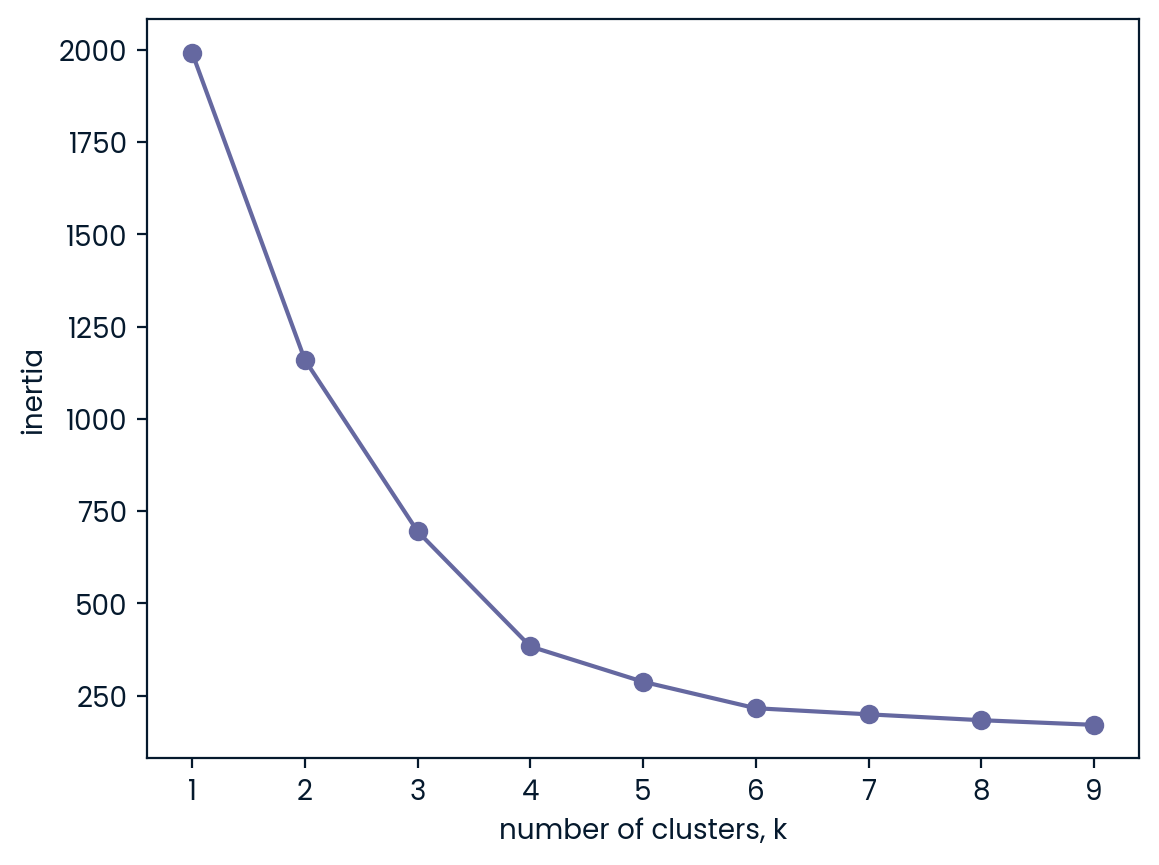

[1992.0000000000007, 1159.9635506619068, 695.197809547408, 383.46432033536416, 287.7481362875542, 216.06711783673342, 199.5254527295771, 183.60417224545944, 171.0464307821656]


In [13]:
# Detect the optimal number of clusters for k-means clustering
ks = range(1,10)
inertias = []
for k in ks:
    # Create a KMeans instance with k clusters: model
    model = KMeans(n_clusters = k, random_state=42).fit(scaled_features)
    
     # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

print(inertias)

     culmen_length_mm  culmen_depth_mm  ...  dummy_MALE  cluster
0                39.1             18.7  ...           1        0
1                39.5             17.4  ...           0        1
2                40.3             18.0  ...           0        1
3                36.7             19.3  ...           0        1
4                39.3             20.6  ...           1        0
..                ...              ...  ...         ...      ...
327              47.2             13.7  ...           0        3
328              46.8             14.3  ...           0        3
329              50.4             15.7  ...           1        2
330              45.2             14.8  ...           0        3
331              49.9             16.1  ...           1        2

[332 rows x 7 columns]


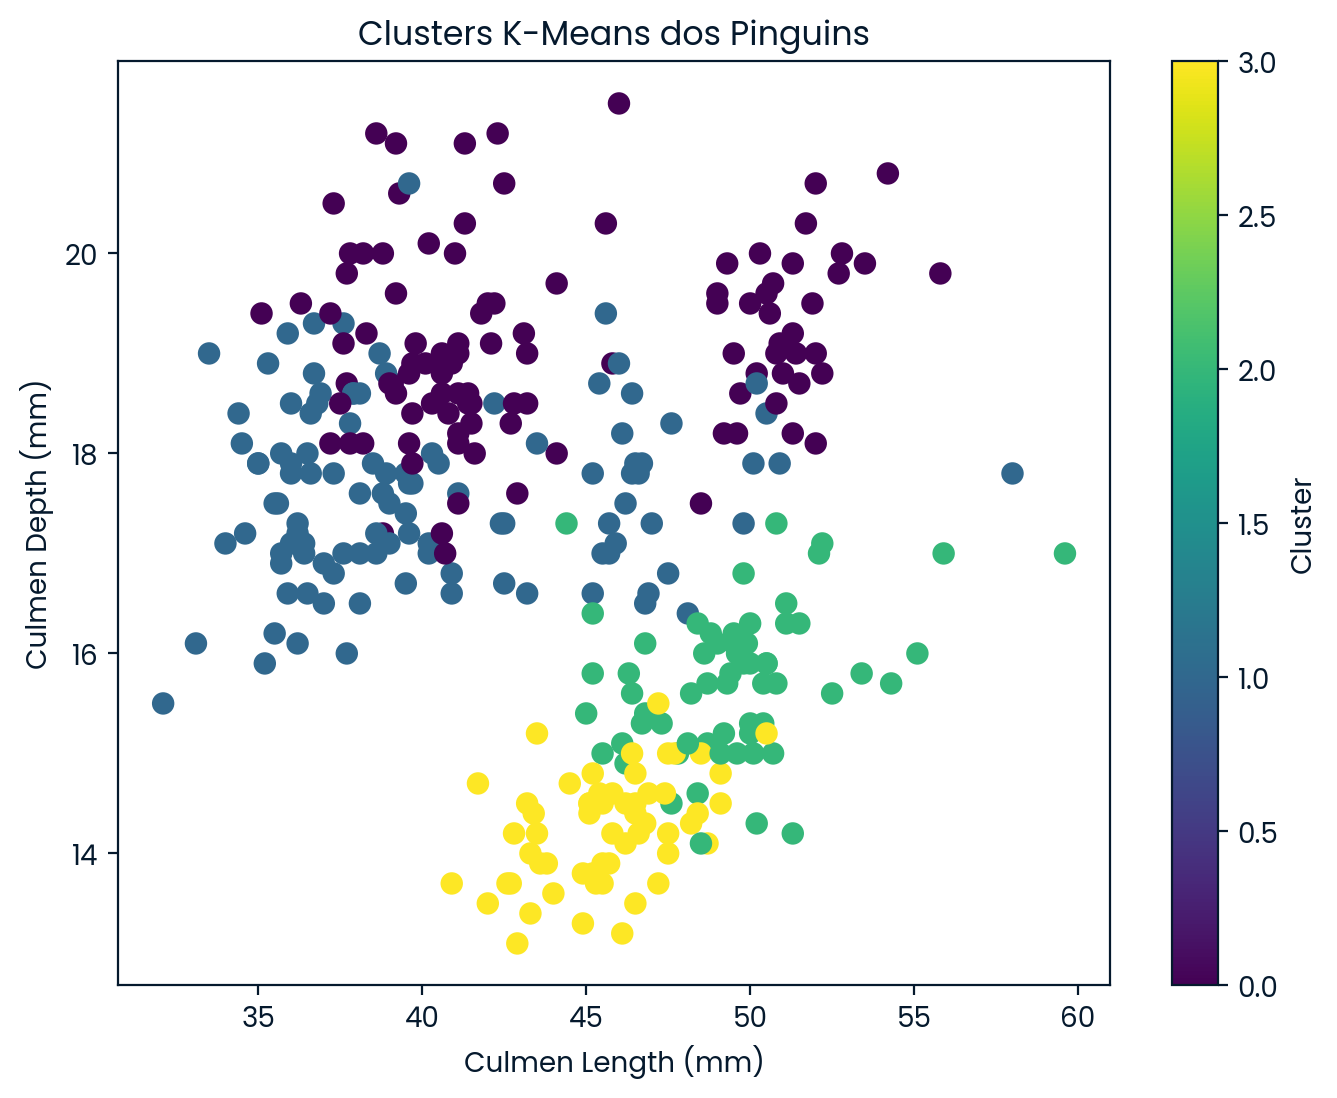

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit_predict(scaled_features)

labels = kmeans.labels_

penguins_df_dum['cluster'] = labels
print(penguins_df_dum)

# Visualize the clusters 
plt.figure(figsize=(8,6))
plt.scatter(penguins_df_dum['culmen_length_mm'], penguins_df_dum['culmen_depth_mm'], 
            c=penguins_df_dum['cluster'], cmap='viridis', s=50)
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Culmen Depth (mm)')
plt.title('Clusters K-Means dos Pinguins')
plt.colorbar(label='Cluster')
plt.show()

In [15]:
numeric_columns = penguins_df_dum.select_dtypes(include=['float64', 'int64']).columns

stat_penguins = penguins_df_dum[numeric_columns].groupby(penguins_df_dum['cluster']).mean()

print(stat_penguins)


         culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
cluster                                                                   
0               43.878302        19.111321         194.764151  4006.603774
1               40.217757        17.611215         189.046729  3419.158879
2               49.473770        15.718033         221.540984  5484.836066
3               45.563793        14.237931         212.706897  4679.741379
